<a href="https://colab.research.google.com/github/Nurdaylight/An-Econ-771/blob/main/PS3/PS3_optim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from scipy.stats import norm
import numpy as np
import torch
import matplotlib.pyplot as plt
import math

## **Notice**
### Calculations mostly are done in one BATCH tensor.

### Answer cells simply call into element of the tensor

In [2]:
# This is for the timing of the code run time, please do not modify
import time
start_time = time.time()

## Exercise I

<blockquote>

<b>

In this exercise we would like to study the finite-sample distribution of the OLS estimator using Monte Carlo simulations. Simulate $M$ $(M \geq 5000)$ i.i.d. samples of size $n = 20$ as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \epsilon,$$

with coefficients set to $\beta_1 = 1$, $\beta_2 = 2$, $\beta_3 = 3$ and the data generated as $X_2 \sim N(0, 1)$, $X_3 \sim N(0, 1)$, $\epsilon \sim N(0, 1)$ with $X_2 \coprod X_3 \coprod \epsilon$.

</b>

</blockquote>

**1. Explore the distribution of the OLS estimator under the homoskedastic Gaussian errors as follows:**

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#Params

M = 5000
n = 20
beta_true = torch.tensor([1.0, 2.0, 3.0], device=device)  # (β1, β2, β3)

#>--------------------------------------------------------

# Generate tensor of all data with dimensions M*N*K
# Create one part and duplicate it to ensure they are identical
X_part = torch.randn(M, n, 3, device=device)
X = torch.stack([X_part, X_part], dim=0)
X[1,:, :, 0] = X[1,:, :, 0] * (X[1,:, :, 1] + X[1,:, :, 2])
Y= X@beta_true +1.0
#Replace constant for regressions
X[:,:, :, 0] = 1.0

In [4]:
# Compute estimates
XtX = X.transpose(2, 3) @ X      # shape: (2, M, 3, 3)
XtX_inv = torch.linalg.inv(XtX)  # shape: (2, M, 3, 3)

beta_hat= XtX_inv @ X.transpose(2, 3)@Y.view(2,M, n, 1)



**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**


**Answer:** all estimates are stored in `beta_hat` shaped `[2, 5000, 3, 1]` 2\*M\*n*1. First element in dimension 0 stores OLS estimates under homoskedasticity.


In [5]:
beta_hat[0].view(M,3)

tensor([[0.7299, 1.9192, 3.1270],
        [1.3252, 2.0444, 2.5287],
        [0.8890, 1.9800, 2.9646],
        ...,
        [0.8771, 1.8093, 2.9099],
        [1.0165, 2.2337, 2.8742],
        [1.2289, 1.6616, 2.7194]], device='cuda:0')

**(b) Plot three histograms of standardized estimators, i.e., plot the histogram of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\sigma^2 (X^T X)^{-1}}}$ assuming that $\sigma^2$ is known. Plot the probability density function of $N(0, 1)$ at each histogram.**

In [6]:
#Comute standard errors

# ---- extract diagonal using torch ONLY ----
XtX_inv_diag = torch.diagonal(XtX_inv, dim1=2, dim2=3)   # (2, M, 3)

# se
se = torch.sqrt(1 * XtX_inv_diag)
diff= (beta_hat - beta_true.view(1,-1,1)).squeeze(-1)

# The z scores are:
z= diff/se


In [7]:
# precompute all edges and stuff for plots
edges = torch.linspace(-4, 4, 31, device="cpu")   # 30 bins
widths = (edges[1:] - edges[:-1])
centers = 0.5 * (edges[1:] + edges[:-1])

# standard normal pdf
phi = (1 / math.sqrt(2 * math.pi)) * torch.exp(-0.5 * centers**2)

# Compute counts as a single tensor of shape (3, 30)
counts = torch.stack([torch.histc(z[0, :, i], bins=30, min=-4.0, max=4.0)
                      for i in range(3)], dim=0).cpu()

density = counts / (counts.sum(dim=1, keepdim=True) * widths.unsqueeze(0))
#Computing t scores:
error_hat= Y.view(2,M,n,1) - (X@beta_hat)
var=error_hat.transpose(2,3)@error_hat /(n-3)
se_hat=torch.sqrt(var.squeeze(-1)   * XtX_inv_diag)
t=diff /se_hat


**Answer:**

**Please see row 1** for plots required.


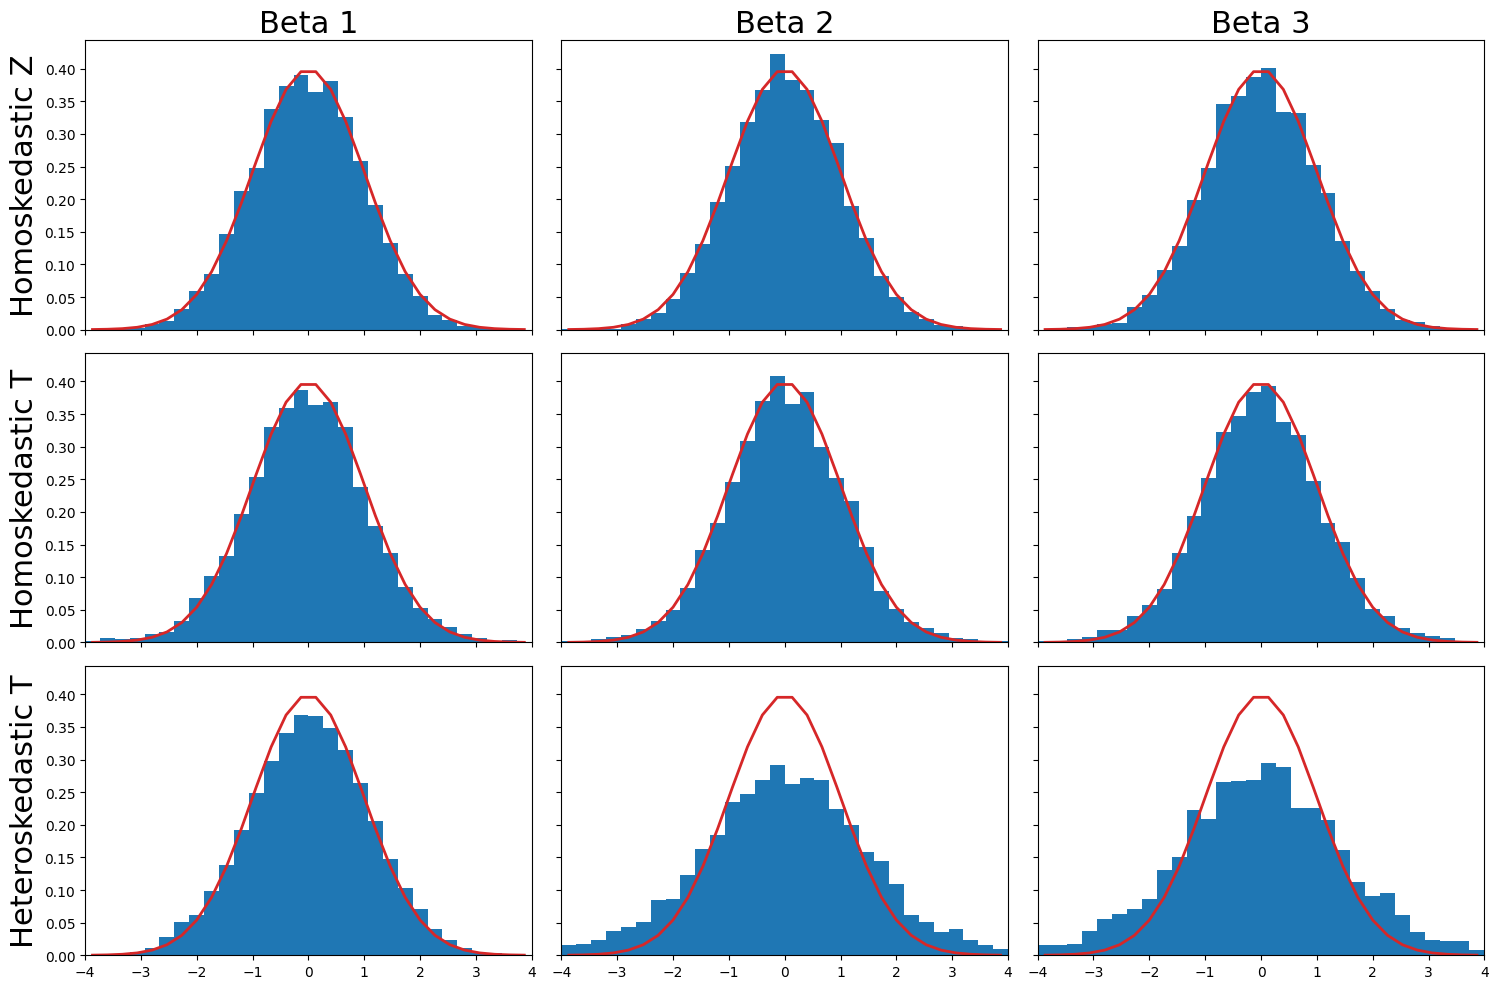

In [8]:

# 1. Prepare Data
counts_z = torch.stack([torch.histc(z[0, :, i], bins=30, min=-4.0, max=4.0) for i in range(3)], dim=0).cpu()
density_z = counts_z / (counts_z.sum(dim=1, keepdim=True) * widths.unsqueeze(0))

# T distributions (from t, containing both Homo [0] and Hetero [1])
counts_t = torch.stack([
    torch.stack([torch.histc(t[j, :, i], bins=30, min=-4.0, max=4.0) for i in range(3)], dim=0)
    for j in range(2)
], dim=0).cpu()
density_t = counts_t / (counts_t.sum(dim=2, keepdim=True) * widths)

# Gather densities: [Homo Z, Homo T, Hetero T]
# density_z shape: (3, 30)
# density_t shape: (2, 3, 30)
plot_data = [density_z, density_t[0], density_t[1]]
row_titles = ["Homoskedastic Z", "Homoskedastic T", "Heteroskedastic T"]

# 2. Plot on Grid
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharey=True, sharex=True)

for row in range(3):
    for col in range(3):
        ax = axes[row, col]
        ax.stairs(plot_data[row][col], edges, fill=True)
        # Plot  Normal PDF
        ax.plot(centers, phi, color="tab:red", linewidth=2)
        if row == 0:
            ax.set_title(f"Beta {col+1}", fontsize = 22)
        if col == 0:
            ax.set_ylabel(row_titles[row], fontsize = 22)
        ax.set_xlim(-4, 4)
plt.tight_layout()
plt.show()

**(c) Replace $\sigma^2$ by its unbiased estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

**Answer:**

1.   Please see **row 2** of the plot above,
2.   this estimator is distributed according to F distribution with **n-k (17)** degrees of freedom.





**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct (For each coefficient you should test the null hypothesis that it actually equals to the one set in the datagenerating process and compare the value of the t-statistics to the quantiles of the distribution that you observe in (c)).**

**Answer:**

Please see cell output below.

(Note) critical value was found from "t-table"

In [9]:
crit=  2.110 #Analytical
false_pos = (torch.sum((t > crit) | (t < -crit), dim=1))/M
print(f"rate of false positives is {false_pos[0].tolist()}")

rate of false positives is [0.047599997371435165, 0.047199998050928116, 0.053999997675418854]


**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

**Answer:**

Please see cell output below.

In [10]:
#F

t_0=beta_hat.squeeze(-1) /se_hat
false_pos_0 = (torch.sum((t_0 > crit) | (t_0 < -crit), dim=1))/M
print(f"Rate of two sided null rejection is {false_pos_0[0].tolist()}")

Rate of two sided null rejection is [0.9771999716758728, 1.0, 1.0]


**(f) Conclude.**


**Answer:**


Part (d): The calculated 'false_pos' represents the rate of Type I errors (incorrectly rejecting the true null hypothesis)

when using the t-statistic (with estimated variance) to test if `beta_true` is different from the estimated beta_hat.

the rate was relativeley close to the chosen significance level (e.g., 0.05). Which empirically supports the fact that it is indeed t-distributed variable.


Part (e): The 'false_pos_0' represents the rate at which the null hypothesis (`beta = 0`) is rejected.

Since the true betas (`beta_true`) are `[1.0, 2.0, 3.0]` and are not zero, we expect a high rejection rate for `beta = 0`.

This indicates the power of the test to correctly reject a false null hypothesis. We can see this value increased in absolute size of beta. If true beta is different from zero but very close it, is harder to differenciate it compared to the case with large absolute betas.

<b>

2. Now we introduce heteroskedasticity as follows
$$Y = \beta_1 + \beta_2 X_2 + \beta_3 X_3 + \tilde{\epsilon},$$

where $\tilde{\epsilon} = \epsilon(X_2 + X_3)$ and the rest is simulated as before. Check that $E[\tilde{\epsilon}|X_2, X_3] = 0$ and $Var(\tilde{\epsilon}|X_2, X_3) = (X_2 + X_3)^2$. Simulate new data and explore the the distribution of the OLS estimator under heteroskedastic normal errors following steps (a) and (c)-(e) above.

</b>

**(0) Check that $E[\tilde{\epsilon}|X_2, X_3] = 0$ and $Var(\tilde{\epsilon}|X_2, X_3) = (X_2 + X_3)^2$.**

**(a) For each $m = 1, \dots, M$, compute the OLS estimator $\hat{\beta}_m = (\hat{\beta}_{1m}, \hat{\beta}_{2m}, \hat{\beta}_{3m})^T$.**

**Answer:** all estimates are stored in `beta_hat` shaped `[2, 5000, 3, 1]` 2\*M\*n*1. Second element in dimension 0 stores OLS estimates under heteroscedasticity.

Below is part of this huge tensor.


In [11]:
beta_hat[1].view(M,3)

tensor([[1.0689, 2.1982, 2.8540],
        [0.6973, 2.0011, 3.6097],
        [1.0104, 1.7604, 2.6833],
        ...,
        [0.9945, 2.2994, 3.1797],
        [1.3322, 2.2050, 2.9046],
        [0.6007, 2.7338, 3.5266]], device='cuda:0')

**(c) Replace $\sigma^2$ by its unbiased estimator $\hat{\sigma}^2$ and plot histograms of $\frac{\hat{\beta}_{km} - \beta_{km}}{\sqrt{\hat{\sigma}^2 (X^T X)^{-1}}}$ with the probability function of $N(0, 1)$. What is the distribution of the standardized estimators now?**

**Answer:**

**Please see row 3** for plots required under answer for **No.1 b)**

**(d) Fix significance level at 5%. Compute the empirical size of the t-test – the fraction of times you reject the null-hypothesis when it is actually correct.**

**Answer:**

Please see cell output below.

In [12]:
print(f"rate of false positives is {false_pos[1].tolist()}")

rate of false positives is [0.050200000405311584, 0.1517999917268753, 0.1589999943971634]


**(e) Compute the empirical power of the t-test for the significance test ($H_0 : \beta_k = 0$) – the fraction of times you reject the null-hypothesis.**

**Answer:**

Please see cell output below.

In [13]:
print(f"Rate of two sided null rejection is {false_pos_0[1].tolist()}")

Rate of two sided null rejection is [0.8452000021934509, 0.9893999695777893, 1.0]


**(f) Conclude.**

In [14]:
end_time = time.time()
end_time-start_time

3.521700143814087